In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Display first few rows
print(df.head())

# Dataset information
print(df.info())
print(df.describe())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

In [2]:
# Select useful features
features = [
    'survived', 'pclass', 'age', 'sibsp',
    'parch', 'fare', 'adult_male'
]

data = df[features].copy()

# Convert boolean to integer
data['adult_male'] = data['adult_male'].astype(int)

# Fill missing age values with median
data['age'] = data['age'].fillna(data['age'].median())

# Check missing values
print(data.isnull().sum())

print("\nPreprocessed data:")
print(data.head())

survived      0
pclass        0
age           0
sibsp         0
parch         0
fare          0
adult_male    0
dtype: int64

Preprocessed data:
   survived  pclass   age  sibsp  parch     fare  adult_male
0         0       3  22.0      1      0   7.2500           1
1         1       1  38.0      1      0  71.2833           0
2         1       3  26.0      0      0   7.9250           0
3         1       1  35.0      1      0  53.1000           0
4         0       3  35.0      0      0   8.0500           1


In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(data)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (891, 7)


In [4]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
for i, variance in enumerate(explained_variance):
    print(f"PC{i+1}: {variance:.4f}")

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative explained variance:")
for i, variance in enumerate(cumulative_variance):
    print(f"PC{i+1}: {variance:.4f}")

Explained variance ratio:
PC1: 0.3097
PC2: 0.2521
PC3: 0.1616
PC4: 0.0972
PC5: 0.0801
PC6: 0.0521
PC7: 0.0473

Cumulative explained variance:
PC1: 0.3097
PC2: 0.5618
PC3: 0.7233
PC4: 0.8205
PC5: 0.9006
PC6: 0.9527
PC7: 1.0000


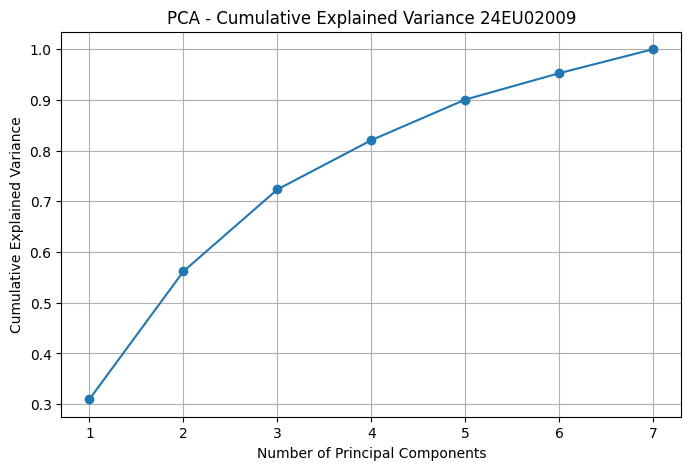

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance 24EU02009")
plt.grid(True)
plt.show()

In [7]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca_2,
    columns=['PC1', 'PC2']
)

print(pca_df.head())

print("\nVariance explained by 2 PCs:",
      pca_2.explained_variance_ratio_.sum())

        PC1       PC2
0  1.232443  0.935026
1 -1.897254 -1.461784
2 -0.452261  0.419702
3 -1.769116 -1.225391
4  1.616926  0.055023

Variance explained by 2 PCs: 0.5617771393716033


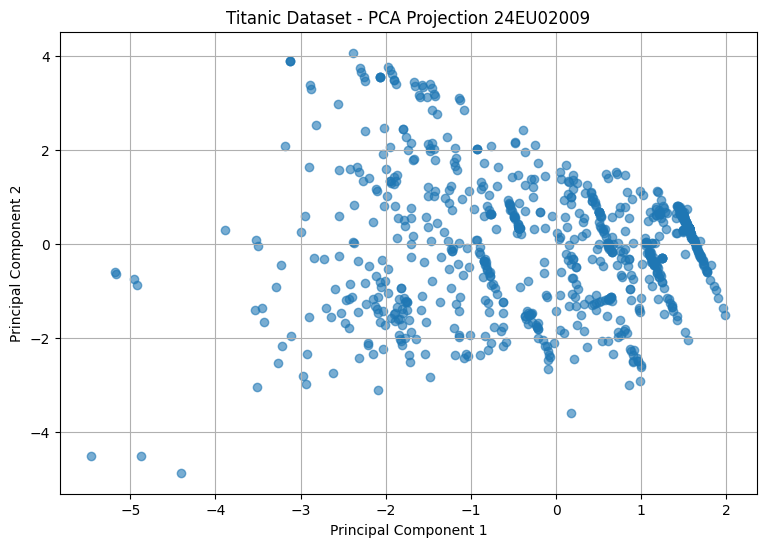

In [9]:
plt.figure(figsize=(9, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Titanic Dataset - PCA Projection 24EU02009")
plt.grid(True)
plt.show()

In [10]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

print("PCA Loadings:")
print(loadings)

PCA Loadings:
                 PC1       PC2
survived   -0.454506 -0.170417
pclass      0.311459  0.563757
age         0.123750 -0.521815
sibsp      -0.295088  0.389685
parch      -0.383233  0.313919
fare       -0.427921 -0.317082
adult_male  0.513851 -0.172927


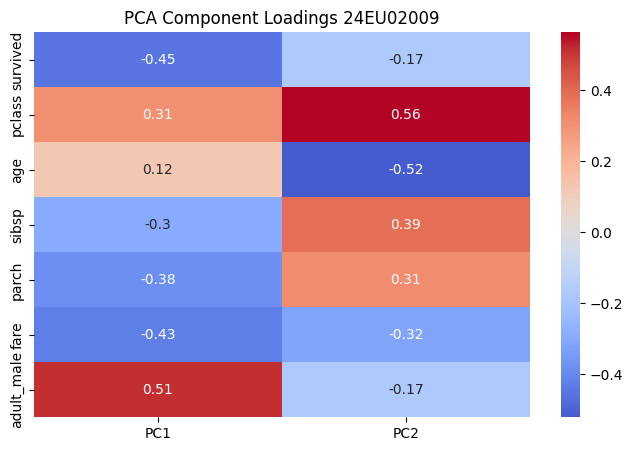

In [12]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    loadings,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("PCA Component Loadings 24EU02009")
plt.show()

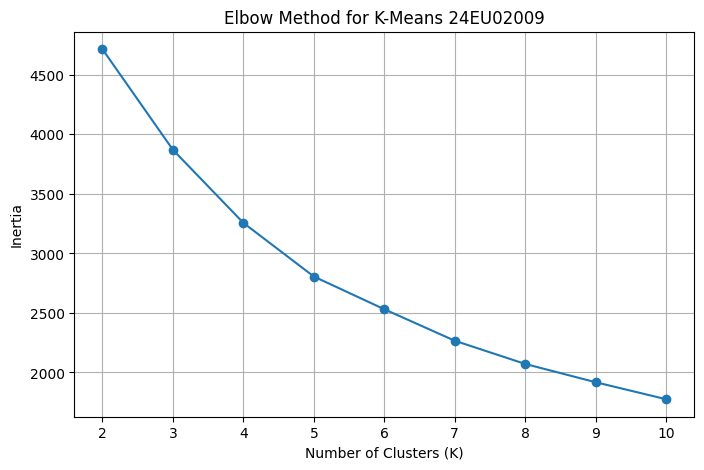

In [14]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means 24EU02009")
plt.grid(True)
plt.show()

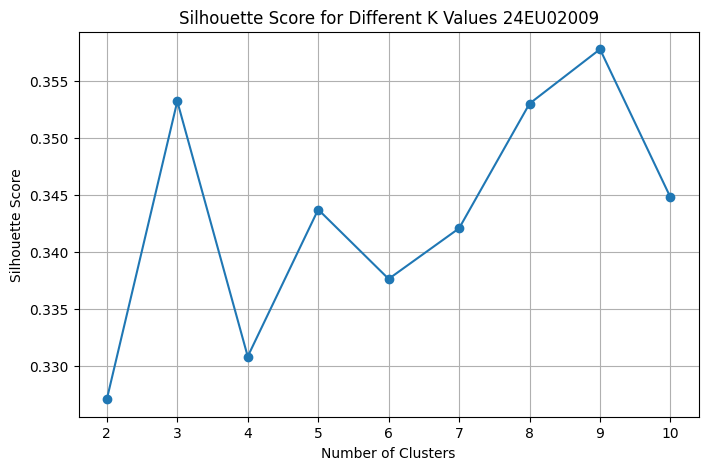

K=2: Silhouette Score=0.3271
K=3: Silhouette Score=0.3532
K=4: Silhouette Score=0.3308
K=5: Silhouette Score=0.3437
K=6: Silhouette Score=0.3376
K=7: Silhouette Score=0.3421
K=8: Silhouette Score=0.3530
K=9: Silhouette Score=0.3578
K=10: Silhouette Score=0.3448


In [16]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values 24EU02009")
plt.grid(True)
plt.show()

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")

In [17]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original data
data['Cluster'] = clusters

print(data.head())

   survived  pclass   age  sibsp  parch     fare  adult_male  Cluster
0         0       3  22.0      1      0   7.2500           1        0
1         1       1  38.0      1      0  71.2833           0        1
2         1       3  26.0      0      0   7.9250           0        1
3         1       1  35.0      1      0  53.1000           0        1
4         0       3  35.0      0      0   8.0500           1        0


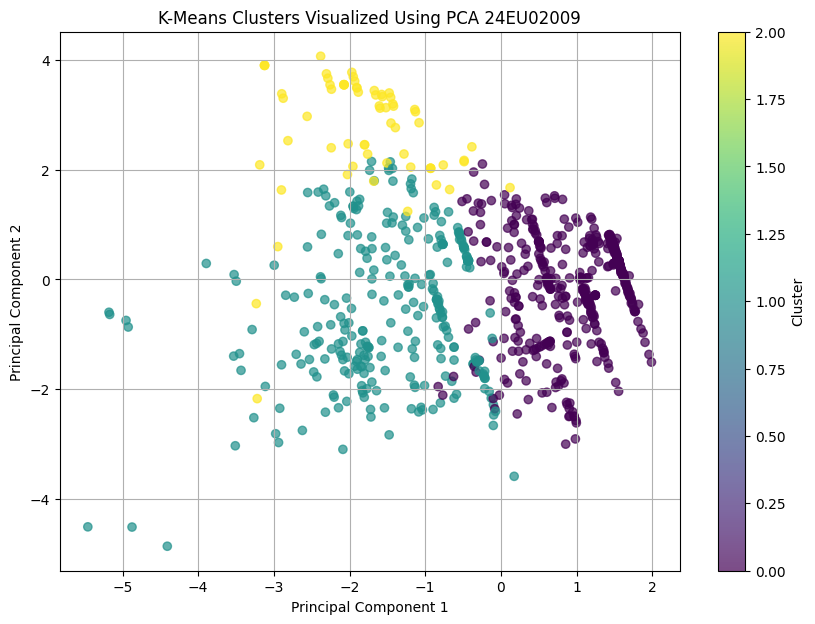

In [19]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA 24EU02009")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)
plt.show()

In [20]:
cluster_summary = data.groupby('Cluster').mean()

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         survived    pclass        age     sibsp     parch       fare  \
Cluster                                                                 
0        0.084746  2.538606  31.134652  0.220339  0.107345  17.073091   
1        0.976271  1.766102  28.793797  0.457627  0.484746  56.932798   
2        0.138462  2.892308  17.453846  3.292308  2.153846  43.584038   

         adult_male  
Cluster              
0          0.902072  
1          0.159322  
2          0.169231  


In [21]:
print("\nNumber of passengers in each cluster:")
print(data['Cluster'].value_counts().sort_index())


Number of passengers in each cluster:
Cluster
0    531
1    295
2     65
Name: count, dtype: int64


In [22]:
cluster_features = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',
    'adult_male'
]

X_cluster = df[cluster_features].copy()

X_cluster['adult_male'] = X_cluster['adult_male'].astype(int)

X_cluster['age'] = X_cluster['age'].fillna(
    X_cluster['age'].median()
)

X_cluster['fare'] = X_cluster['fare'].fillna(
    X_cluster['fare'].median()
)

# Standardize
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Add clusters
df_analysis = df.copy()
df_analysis['Cluster'] = cluster_labels

# Cluster characteristics
print(
    df_analysis.groupby('Cluster')[
        ['survived', 'pclass', 'age', 'fare']
    ].mean()
)

         survived    pclass        age       fare
Cluster                                          
0        0.595745  1.140426  41.500000  70.690834
1        0.510067  2.550336  15.827045  40.652824
2        0.248521  2.779093  28.139257  11.882313
